# Kwant — Theory and Practice · Chapter 11
## Higher-order topology and Weyl semimetals

*Part II · Sections 24–25 · Figures 59–65* &nbsp;·&nbsp; [← Chapter 10](10_Z2_and_Chiral_Superconductors.ipynb) · [Contents](00_Contents.ipynb) · [Chapter 12 →](12_3D_TI_Exercises_II_and_Beyond.ipynb)

### In this chapter

- [24. The BBH quadrupole — higher-order topology](#24.-The-BBH-quadrupole-—-higher-order-topology)
- [25. Weyl semimetals — Fermi arcs from sliced Chern numbers](#25.-Weyl-semimetals-—-Fermi-arcs-from-sliced-Chern-numbers)

Run the **Setup** cell first: it imports Kwant, reports the sparse solver, mutes three library warnings and defines `show_fig`, whose figure counter continues the course-wide numbering. Each chapter is self-contained given its Setup cell (a *carried over* cell, where present, rebuilds an object defined in an earlier chapter). Installation, the `kwant` kernel and the conventions are in [`00_Contents.ipynb`](00_Contents.ipynb).

`SPDX-License-Identifier: Apache-2.0` — Copyright 2026 Fabio Campolim.


In [1]:
# --- Setup: run this cell first ----------------------------------------------
# Imports, the sparse-solver report, three muted library warnings, and the
# figure helper.  Every chapter of the course starts with this cell.
import kwant
import numpy as np
import scipy
import tinyarray as ta                   # noqa: F401  (used by later cells)
import matplotlib
from matplotlib import pyplot

print("kwant", kwant.__version__, "| numpy", np.__version__,
      "| scipy", scipy.__version__, "| matplotlib", matplotlib.__version__)

# Which sparse solver is active? MUMPS is much faster than SciPy's SuperLU.
import kwant.solvers.default
print("default solver:", kwant.solvers.default.__name__)
try:
    import kwant.solvers.mumps          # noqa: F401
    print("MUMPS available: yes")
except ImportError:
    print("MUMPS available: no  (falling back to scipy sparse -> slower)")

matplotlib.rcParams['figure.figsize'] = (7, 5)

# Mute three library warnings that are not ours to fix and would otherwise be
# printed under some figures.  Done by wrapping warnings.showwarning rather than
# with warnings.filterwarnings(), because kwant.plotter calls
# warnings.resetwarnings() on every 3D plot, which silently deletes all user
# filters (reported upstream).  Only these three messages are muted:
#  * kwant 1.5.0's 3D plotter calls a matplotlib function deprecated in 3.10
#    (fixed on Kwant's main branch, unreleased);
#  * mpmath (via sympy) uses a deprecated bitcount helper;
#  * kwant.plotter.map notes that a few density values exceed the colour range,
#    which is expected for the delta-like densities in sections 6 and 12.
import warnings
_MUTED = ('proj_transform_clip', 'bitcount function is deprecated', 'overflowing upper limit')
_showwarning = warnings.showwarning

def _quiet_showwarning(message, category, filename, lineno, file=None, line=None):
    if not any(k in str(message) for k in _MUTED):
        _showwarning(message, category, filename, lineno, file, line)

warnings.showwarning = _quiet_showwarning

# --- Figure helper ------------------------------------------------------------
# Every figure ends with show_fig("..."), which stamps an auto-numbered italic
# caption under the figure and then shows it.  Figures are numbered
# continuously across the chapters of the course: this chapter's figures are
# 59–65, so the counter starts at 58.  (Re-running a single cell out of
# order advances it -- harmless, but numbers shift.)
_FIG_NO = [58]

def show_fig(caption=None):
    if caption:
        _FIG_NO[0] += 1
        fig = pyplot.gcf()
        fig.text(0.5, -0.02, f"Figure {_FIG_NO[0]}: {caption}",
                 ha='center', va='top', fontsize=9, style='italic',
                 wrap=True, transform=fig.transFigure)
    pyplot.show()


kwant 1.5.0 | numpy 2.5.1 | scipy 1.18.0 | matplotlib 3.10.7
default solver: kwant.solvers.default
MUMPS available: yes


In [2]:
# --- Carried over from section 20 -----------------------------------
# `chern_fhs`, the Fukui–Hatsugai–Suzuki Chern number of § 20.
# The code is the definition of section 20, verbatim.
import kwant, numpy as np
from matplotlib import pyplot

def chern_fhs(hfunc, n_occ, n1=40, n2=40):
    """Chern number by the Fukui-Hatsugai-Suzuki plaquette method.

    hfunc(x1, x2): Bloch Hamiltonian, 2pi-periodic in both arguments.  The
    result is exactly integer on any grid fine enough to resolve the gap.
    (Reused by every 2D section below.)
    """
    xs1 = np.linspace(0, 2 * np.pi, n1, endpoint=False)
    xs2 = np.linspace(0, 2 * np.pi, n2, endpoint=False)
    frames = np.empty((n1, n2), dtype=object)
    for i, x1 in enumerate(xs1):
        for j, x2 in enumerate(xs2):
            frames[i, j] = np.linalg.eigh(hfunc(x1, x2))[1][:, :n_occ]
    link = lambda a, b: np.linalg.det(a.conj().T @ b)
    F = 0.0
    for i in range(n1):
        for j in range(n2):
            u1 = link(frames[i, j], frames[(i+1) % n1, j])
            u2 = link(frames[(i+1) % n1, j], frames[(i+1) % n1, (j+1) % n2])
            u3 = link(frames[(i+1) % n1, (j+1) % n2], frames[i, (j+1) % n2])
            u4 = link(frames[i, (j+1) % n2], frames[i, j])
            F += np.angle(u1 * u2 * u3 * u4)
    return int(round(F / (2 * np.pi)))

print('chern_fhs', 'ready')


chern_fhs ready


---
## 24. The BBH quadrupole — higher-order topology

Benalcazar, Bernevig & Hughes [Science **357**, 61 (2017)] found insulators
whose boundary is *also* gapped, yet still topological: the protected states
live two dimensions down, at the **corners**.  The model is a square lattice
with four sites per cell, $\pi$ flux per plaquette, intra-cell hopping
$\gamma$ and inter-cell hopping $\lambda$:

$$H(\mathbf{k}) = \begin{pmatrix} 0 & q(\mathbf{k}) \\ q^\dagger(\mathbf{k}) & 0
\end{pmatrix},\qquad
q = \begin{pmatrix} \gamma + \lambda e^{ik_x} & \gamma + \lambda e^{ik_y} \\
 -(\gamma + \lambda e^{-ik_y}) & \gamma + \lambda e^{-ik_x} \end{pmatrix}.$$

The dipole (Chern/polarization) invariants all vanish.  The right invariant is
*nested*: first a Wilson loop over $k_y$ at each $k_x$ gives the **Wannier
bands** $\nu_\pm(k_x)$ — themselves gapped, like an effective 1D spectrum —
then the polarization *of a Wannier band* gives the quadrupole moment

$$q_{xy} = \tfrac{1}{2}\ (\gamma < \lambda), \qquad 0\ (\gamma > \lambda).$$

Bulk–boundary correspondence, twice removed: $q_{xy}=1/2$ forces four
zero-energy corner states carrying charge $\pm e/2$ each.

*Experiments:* the BBH model was realised almost immediately in three
platforms in the same year — mechanical metamaterials [Serra-Garcia *et
al.*, Nature **555**, 342 (2018)], microwave circuits [Peterson *et al.*,
Nature **555**, 346 (2018)] and electrical circuit lattices [Imhof *et
al.*, Nat. Phys. **14**, 925 (2018)].  In electronic matter, bismuth again
leads: hinge states of a higher-order phase were reported in Schindler *et
al.*, Nat. Phys. **14**, 918 (2018).  Review: Xie *et al.*, Nat. Rev. Phys.
**3**, 520 (2021).


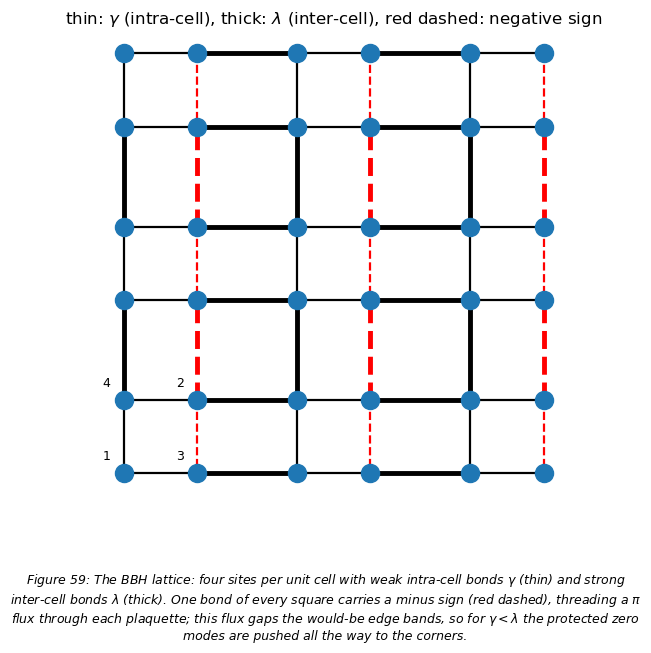

In [3]:
# --- geometry: the BBH unit cell and its pi fluxes ---------------------------
import numpy as np
from matplotlib import pyplot

fig, ax = pyplot.subplots(figsize=(6.5, 6))
pos = {0: (0, 0), 1: (1, 1), 2: (1, 0), 3: (0, 1)}   # = basis order of h_bbh

def draw_cell(ox, oy, first):
    P = {k: (ox + x * 0.55, oy + y * 0.55) for k, (x, y) in pos.items()}
    intra = [(0, 2, +1), (1, 3, +1),          # horizontals, both +gamma
             (0, 3, +1), (1, 2, -1)]          # verticals: right one -gamma
    for a, b, sgn in intra:
        ax.plot(*zip(P[a], P[b]), color='k' if sgn > 0 else 'r',
                ls='-' if sgn > 0 else '--', lw=1.6)
    for k, (x, y) in P.items():
        ax.plot(x, y, 'o', ms=13, color='C0', zorder=3)
        if first:
            ax.text(x - 0.16, y + 0.10, str(k + 1), fontsize=9)

for ox in (0, 1.3, 2.6):
    for oy in (0, 1.3, 2.6):
        draw_cell(ox, oy, ox == 0 and oy == 0)
for ox in (0, 1.3):                            # inter-cell (lambda) bonds
    for oy in (0, 1.3, 2.6):
        ax.plot([ox + 0.55, ox + 1.3], [oy, oy], 'k-', lw=3.5)
        ax.plot([ox + 0.55, ox + 1.3], [oy + 0.55, oy + 0.55], 'k-', lw=3.5)
for oy in (0, 1.3):
    for ox in (0, 1.3, 2.6):
        ax.plot([ox, ox], [oy + 0.55, oy + 1.3], 'k-', lw=3.5)
        ax.plot([ox + 0.55, ox + 0.55], [oy + 0.55, oy + 1.3], 'r--', lw=3.5)
ax.set_aspect('equal')
ax.set_axis_off()
ax.set_title(r'thin: $\gamma$ (intra-cell), thick: $\lambda$ (inter-cell), '
             r'red dashed: negative sign')
show_fig(r'The BBH lattice: four sites per unit cell with weak intra-cell bonds $\gamma$ (thin) and strong inter-cell bonds $\lambda$ (thick). One bond of every square carries a minus sign (red dashed), threading a $\pi$ flux through each plaquette; this flux gaps the would-be edge bands, so for $\gamma<\lambda$ the protected zero modes are pushed all the way to the corners.')

quadrupole q_xy:  topological = 0.5000  trivial = 0.0000


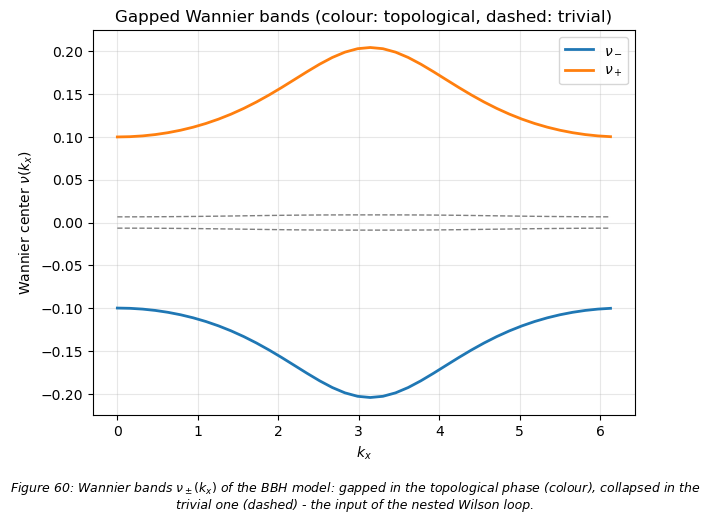

four in-gap corner modes at E = [ 1.e-05 -1.e-05  1.e-05 -1.e-05]


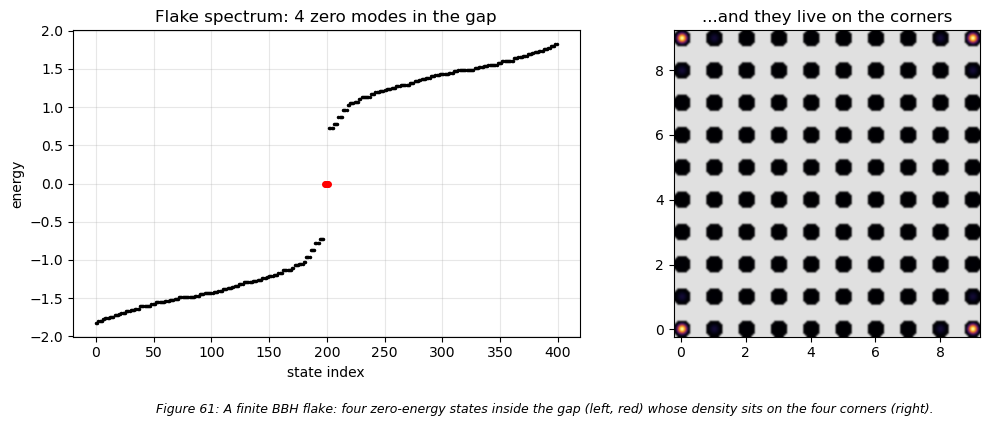

trivial flake: smallest |E| = 1.013  (no midgap states)


In [4]:
# --- BBH quadrupole: Wannier bands, nested Wilson loop, corner states ---------
import kwant, numpy as np
from matplotlib import pyplot

gam, lam = 0.3, 1.0                 # topological: gam < lam

def h_bbh(kx, ky, gam=gam, lam=lam):
    q = np.array([[gam + lam * np.exp(1j * kx), gam + lam * np.exp(1j * ky)],
                  [-(gam + lam * np.exp(-1j * ky)), gam + lam * np.exp(-1j * kx)]])
    z = np.zeros((2, 2))
    return np.block([[z, q], [q.conj().T, z]])

def wannier_bands(gam, lam, N=40):
    """Wilson loop over ky at each kx; eigenphases/2pi = Wannier centers."""
    ks = np.linspace(0, 2 * np.pi, N, endpoint=False)
    u = np.empty((N, N), dtype=object)
    for i, kx in enumerate(ks):
        for j, ky in enumerate(ks):
            u[i, j] = np.linalg.eigh(h_bbh(kx, ky, gam, lam))[1][:, :2]
    centers, states = [], []
    for i in range(N):
        W = np.eye(2, dtype=complex)
        for j in range(N):
            F = u[i, j].conj().T @ u[i, (j + 1) % N]
            uu, _, vv = np.linalg.svd(F)        # unitarize the link
            W = W @ (uu @ vv)
        ph, vec = np.linalg.eig(W)
        nu = np.angle(ph) / (2 * np.pi)
        order = np.argsort(nu)
        centers.append(nu[order])
        states.append(u[i, 0] @ vec[:, order])  # Wannier-band basis
    return ks, np.array(centers), states

def nested_polarization(states):
    """Polarization of the upper Wannier band along kx: the quadrupole q_xy."""
    N = len(states)
    prod = 1.0 + 0j
    for i in range(N):
        prod *= np.vdot(states[i][:, 1], states[(i + 1) % N][:, 1])
    return (-np.angle(prod) / (2 * np.pi)) % 1

ks, nu, wst = wannier_bands(gam, lam)
_, nu_t, wst_t = wannier_bands(1.0, 0.3)        # trivial: gam > lam
print(f"quadrupole q_xy:  topological = {nested_polarization(wst):.4f}  "
      f"trivial = {nested_polarization(wst_t):.4f}")

pyplot.plot(ks, nu[:, 0], 'C0', lw=2, label=r'$\nu_-$')
pyplot.plot(ks, nu[:, 1], 'C1', lw=2, label=r'$\nu_+$')
pyplot.plot(ks, nu_t, 'gray', lw=1, ls='--')
pyplot.xlabel(r"$k_x$"); pyplot.ylabel(r"Wannier center $\nu(k_x)$")
pyplot.title("Gapped Wannier bands (colour: topological, dashed: trivial)")
pyplot.legend(); pyplot.grid(alpha=.3); show_fig(r'Wannier bands $\nu_\pm(k_x)$ of the BBH model: gapped in the topological phase (colour), collapsed in the trivial one (dashed) - the input of the nested Wilson loop.')

# corner states of a finite flake
lat = kwant.lattice.square(norbs=4)

def bbh_flake(gam, lam, Nc=10):
    on = np.array([[0, 0, gam, gam],
                   [0, 0, -gam, gam],
                   [gam, -gam, 0, 0],
                   [gam, gam, 0, 0]], dtype=complex)
    hx = np.zeros((4, 4), dtype=complex); hx[0, 2] = lam; hx[3, 1] = lam
    hy = np.zeros((4, 4), dtype=complex); hy[0, 3] = lam; hy[2, 1] = -lam
    syst = kwant.Builder()
    syst[(lat(x, y) for x in range(Nc) for y in range(Nc))] = on
    syst[kwant.builder.HoppingKind((1, 0), lat, lat)] = hx
    syst[kwant.builder.HoppingKind((0, 1), lat, lat)] = hy
    return syst.finalized()

f_top = bbh_flake(gam, lam)
ev, vec = np.linalg.eigh(f_top.hamiltonian_submatrix())
izero = np.argsort(np.abs(ev))[:4]
print("four in-gap corner modes at E =", np.round(ev[izero], 5))

fig, (ax1, ax2) = pyplot.subplots(1, 2, figsize=(11, 4))
ax1.plot(np.arange(len(ev)), ev, 'k.', ms=3)
ax1.plot(izero, ev[izero], 'r.', ms=8)
ax1.set_xlabel("state index"); ax1.set_ylabel("energy")
ax1.set_title("Flake spectrum: 4 zero modes in the gap")
ax1.grid(alpha=.3)
dens = (np.abs(vec[:, izero]) ** 2).sum(axis=1).reshape(-1, 4).sum(axis=1)
kwant.plotter.density(f_top, dens, ax=ax2, cmap='inferno')
ax2.set_title("...and they live on the corners")
pyplot.tight_layout(); show_fig(r'A finite BBH flake: four zero-energy states inside the gap (left, red) whose density sits on the four corners (right).')

ev_tri = np.linalg.eigvalsh(bbh_flake(1.0, 0.3).hamiltonian_submatrix())
print(f"trivial flake: smallest |E| = {np.abs(ev_tri).min():.3f}  (no midgap states)")

---
## 25. Weyl semimetals — Fermi arcs from sliced Chern numbers

A Weyl semimetal needs no gap at all: its band structure holds isolated
touching points that act as **monopoles of Berry curvature** with chirality
$\pm 1$ [Wan *et al.*, PRB **83**, 205101 (2011); Armitage *et al.*, RMP
**90**, 015001 (2018)].  The minimal two-band lattice model

$$H(\mathbf{k}) = t\sin k_x\,\sigma_x + t\sin k_y\,\sigma_y +
\left[m_0 - t(\cos k_x + \cos k_y + \cos k_z)\right]\sigma_z$$

has two Weyl nodes at $(0,0,\pm k_0)$, $\cos k_0 = m_0/t - 2$.  The key
construction: freeze $k_z$ and regard $H(k_x, k_y; k_z)$ as a family of 2D
insulators.  The slice Chern number $C(k_z)$ **jumps by the chirality** when
$k_z$ sweeps through a node — nonzero exactly *between* the nodes.  Each
nontrivial slice contributes one chiral edge state at $E=0$; strung together
over $|k_z|<k_0$ they form the open **Fermi arc** connecting the projected
nodes on a surface — an object impossible in any isolated 2D system.
(A Kwant-based transport study of this model: the
[WEYLFET repository](https://github.com/GUANGZECHEN/WEYLFET).)

**Physics in more depth.**  A Weyl node cannot be gapped by any local
perturbation — the only way to destroy it is to annihilate it with a node
of opposite chirality, which is why Weyl semimetals need broken inversion
or time-reversal symmetry (Nielsen-Ninomiya theorem: chiralities must sum
to zero on a lattice [Phys. Lett. B **130**, 389 (1983)]).  The same
theorem underlies the **chiral anomaly**: parallel E and B fields pump
charge between the nodes, producing a negative longitudinal
magnetoresistance [Xiong *et al.*, Science **350**, 413 (2015)].

*Experiments:* Fermi arcs were imaged by ARPES in TaAs [Xu *et al.*,
Science **349**, 613 (2015); Lv *et al.*, PRX **5**, 031013 (2015)].
Reviews: Armitage, Mele & Vishwanath, RMP **90**, 015001 (2018); Yan &
Felser, Annu. Rev. Condens. Matter Phys. **8**, 337 (2017).


gap at (0,0,+-k0): 0.0e+00   (k0 = 1.0472)


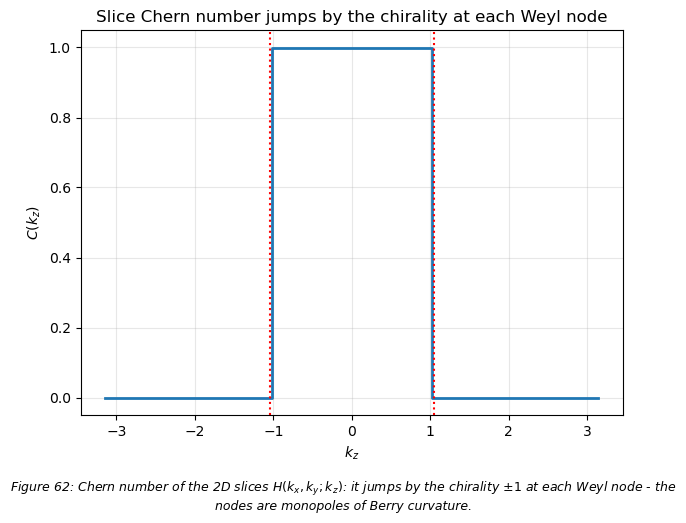

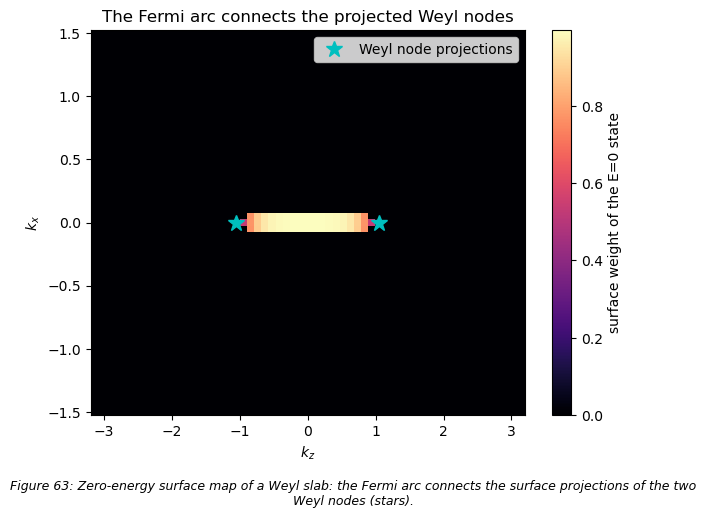

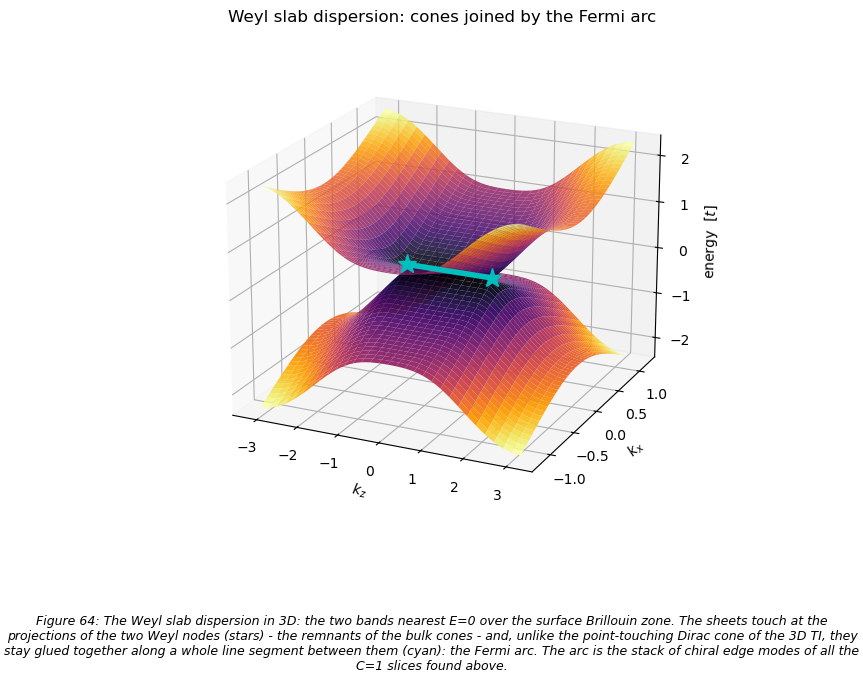

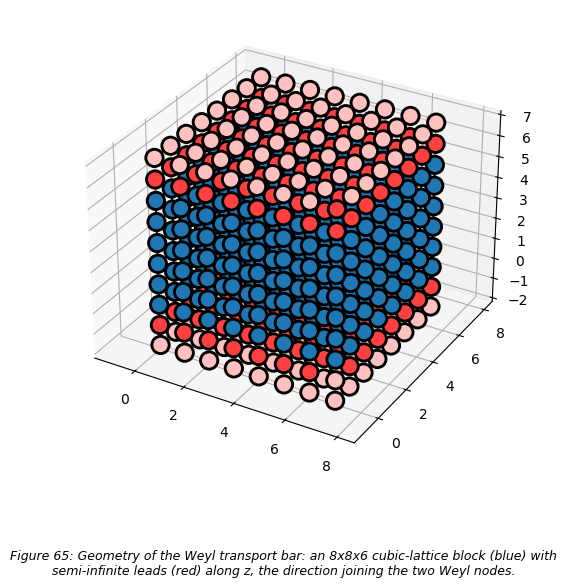

E=0.05:  G = 0.00 e^2/h


E=0.3:  G = 1.00 e^2/h


E=0.6:  G = 5.00 e^2/h


In [5]:
# --- Weyl semimetal: nodes, sliced Chern numbers, Fermi arcs, transport -------
import kwant, numpy as np
from matplotlib import pyplot

sx = np.array([[0, 1], [1, 0]])
sy = np.array([[0, -1j], [1j, 0]])
sz = np.array([[1, 0], [0, -1]])
t, m0 = 1.0, 2.5
k0 = np.arccos(m0 / t - 2)                  # nodes at (0, 0, +-pi/3)

def h_weyl(kx, ky, kz):
    M = m0 - t * (np.cos(kx) + np.cos(ky) + np.cos(kz))
    return t * np.sin(kx) * sx + t * np.sin(ky) * sy + M * sz

print(f"gap at (0,0,+-k0): {np.abs(np.linalg.eigvalsh(h_weyl(0, 0, k0))).min():.1e}"
      f"   (k0 = {k0:.4f})")

# Chern number of each kz slice: +-1 between the nodes, 0 outside
kzs = np.linspace(-np.pi, np.pi, 41)
Cs = [chern_fhs(lambda kx, ky, kz=kz: h_weyl(kx, ky, kz),
                n_occ=1, n1=18, n2=18) for kz in kzs]
pyplot.step(kzs, Cs, where='mid', lw=2)
pyplot.axvline(-k0, color='r', ls=':'); pyplot.axvline(k0, color='r', ls=':')
pyplot.xlabel(r"$k_z$"); pyplot.ylabel(r"$C(k_z)$")
pyplot.title("Slice Chern number jumps by the chirality at each Weyl node")
pyplot.grid(alpha=.3); show_fig(r'Chern number of the 2D slices $H(k_x,k_y;k_z)$: it jumps by the chirality $\pm1$ at each Weyl node - the nodes are monopoles of Berry curvature.')

# Fermi arc: slab finite in y; scan (kx, kz) for E~0 surface states
Ny = 30
hop_y = -t * (sz + 1j * sy) / 2             # from -t cos(ky) sz + t sin(ky) sy

def slab_h(kx, kz):
    on = t * np.sin(kx) * sx + (m0 - t * np.cos(kx) - t * np.cos(kz)) * sz
    H = np.zeros((2 * Ny, 2 * Ny), dtype=complex)
    for y in range(Ny):
        H[2*y:2*y+2, 2*y:2*y+2] = on
        if y + 1 < Ny:
            H[2*y:2*y+2, 2*y+2:2*y+4] = hop_y
            H[2*y+2:2*y+4, 2*y:2*y+2] = hop_y.conj().T
    return H

kxs = np.linspace(-1.5, 1.5, 61)
kzs = np.linspace(-np.pi, np.pi, 61)
arc = np.zeros((len(kxs), len(kzs)))
for i, kx in enumerate(kxs):
    for j, kz in enumerate(kzs):
        ev, vec = np.linalg.eigh(slab_h(kx, kz))
        i0 = np.argmin(np.abs(ev))
        if abs(ev[i0]) < 0.05:                       # a state at the Fermi level
            d = (np.abs(vec[:, i0]) ** 2).reshape(Ny, 2).sum(axis=1)
            arc[i, j] = d[:4].sum() + d[-4:].sum()   # ...on the surface?

pyplot.pcolormesh(kzs, kxs, arc, shading='auto', cmap='magma')
pyplot.colorbar(label="surface weight of the E=0 state")
pyplot.plot([-k0, k0], [0, 0], 'c*', ms=12, label="Weyl node projections")
pyplot.xlabel(r"$k_z$"); pyplot.ylabel(r"$k_x$")
pyplot.title("The Fermi arc connects the projected Weyl nodes")
pyplot.legend(); show_fig(r'Zero-energy surface map of a Weyl slab: the Fermi arc connects the surface projections of the two Weyl nodes (stars).')

# the same physics in 3D: the two slab bands nearest E=0 over the surface BZ.
# Where the TI cone of section 26 touches at a POINT, these sheets touch along
# a LINE - the Fermi arc - terminating in the two bulk Weyl cones.
kxs3 = np.linspace(-1.2, 1.2, 45)
kzs3 = np.linspace(-np.pi, np.pi, 61)
KX3, KZ3 = np.meshgrid(kxs3, kzs3)
E_up = np.zeros_like(KX3)
E_dn = np.zeros_like(KX3)
for i in range(KX3.shape[0]):
    for j in range(KX3.shape[1]):
        ev_k = np.linalg.eigvalsh(slab_h(KX3[i, j], KZ3[i, j]))
        E_up[i, j] = ev_k[ev_k > 0].min()
        E_dn[i, j] = ev_k[ev_k < 0].max()

fig = pyplot.figure(figsize=(8.5, 6.5))
ax = fig.add_subplot(projection='3d')
ax.plot_surface(KZ3, KX3, E_up, cmap='inferno', linewidth=0,
                antialiased=True, alpha=0.85)
ax.plot_surface(KZ3, KX3, E_dn, cmap='inferno_r', linewidth=0,
                antialiased=True, alpha=0.95)
# draw the arc slightly above E=0 so matplotlib's painter keeps it visible
ax.plot([-k0, k0], [0, 0], [0.05, 0.05], 'c-', lw=4, zorder=10)
ax.plot([-k0, k0], [0, 0], [0.05, 0.05], 'c*', ms=14, zorder=11)
ax.set_xlabel(r'$k_z$')
ax.set_ylabel(r'$k_x$')
ax.set_zlabel('energy  $[t]$')
ax.set_title('Weyl slab dispersion: cones joined by the Fermi arc')
ax.view_init(elev=20, azim=-65)
show_fig(r'The Weyl slab dispersion in 3D: the two bands nearest E=0 over the surface Brillouin zone. The sheets touch at the projections of the two Weyl nodes (stars) - the remnants of the bulk cones - and, unlike the point-touching Dirac cone of the 3D TI, they stay glued together along a whole line segment between them (cyan): the Fermi arc. The arc is the stack of chiral edge modes of all the C=1 slices found above.')

# ballistic transport through a Weyl wire: little at the nodes, much away
lat3 = kwant.lattice.cubic(norbs=2)
hops = {(1, 0, 0): -t * (sz + 1j * sx) / 2,
        (0, 1, 0): -t * (sz + 1j * sy) / 2,
        (0, 0, 1): -t * sz / 2}

def weyl_wire(W=8, L=6):
    def fill(syst, rng):
        syst[(lat3(x, y, z) for x in range(W) for y in range(W) for z in rng)] \
            = m0 * sz
        for d, v in hops.items():
            syst[kwant.builder.HoppingKind(d, lat3, lat3)] = v
    syst = kwant.Builder()
    fill(syst, range(L))
    lead = kwant.Builder(kwant.TranslationalSymmetry((0, 0, -1)))
    fill(lead, [0])
    syst.attach_lead(lead)
    syst.attach_lead(lead.reversed())
    return syst.finalized()

fw = weyl_wire()
kwant.plot(fw, site_size=0.3, hop_lw=0.06, fig_size=(6, 6), show=False)
show_fig(r'Geometry of the Weyl transport bar: an 8x8x6 cubic-lattice block (blue) with semi-infinite leads (red) along z, the direction joining the two Weyl nodes.')
for e in (0.05, 0.3, 0.6):
    print(f"E={e}:  G = {kwant.smatrix(fw, e).transmission(1, 0):.2f} e^2/h")